<a href="https://colab.research.google.com/github/Chinmayisr/bankruptcy_prediction/blob/main/earlyBankruptcyPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install lightgbm imbalanced-learn shap --quiet



In [ ]:
# STEP 2: Import libraries
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE

In [ ]:
# STEP 3: Load dataset from GitHub (REPLACE with your actual raw CSV URL)
url = "https://raw.githubusercontent.com/Chinmayisr/bankruptcy_prediction/refs/heads/main/bankruptcy_data.csv"
df = pd.read_csv(url)

In [ ]:
# STEP 3.5: Handle missing values (Imputation)
# Import SimpleImputer
from sklearn.impute import SimpleImputer

# Create an imputer object
imputer = SimpleImputer(strategy='mean') # You can choose 'median' or 'most_frequent'

# Apply imputation to the DataFrame
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)



In [ ]:
# STEP 4: Separate features and target
X = df_imputed.drop("class", axis=1) # Use the imputed dataframe
y = df_imputed["class"] # Use the imputed dataframe
# %%
# STEP 5: Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# %%

In [ ]:
# STEP 5: Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# STEP 6: Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# STEP 7: Handle class imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
# %%

In [ ]:
# STEP 8: Train LightGBM model
model = lgb.LGBMClassifier(random_state=42)
model.fit(X_train_res, y_train_res)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 33051, number of negative: 33051
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.088717 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16320
[LightGBM] [Info] Number of data points in the train set: 66102, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(random_state=42)

In [ ]:
# STEP 9: Evaluate model
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


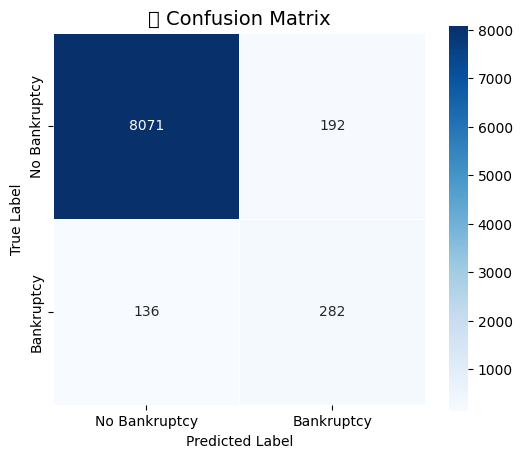

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot using Seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, linewidths=0.5, square=True)
plt.title("📊 Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0.5, 1.5], ["No Bankruptcy", "Bankruptcy"])
plt.yticks([0.5, 1.5], ["No Bankruptcy", "Bankruptcy"])
plt.show()


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# Generate classification report as dict
report_dict = classification_report(y_test, y_pred, output_dict=True)

# Convert to DataFrame
df_report = pd.DataFrame(report_dict).transpose()

# Round values for better readability
df_report = df_report.round(3)

# Display as table
print("📋 Classification Report:\n")
print(df_report)




📋 Classification Report:

              precision  recall  f1-score   support
0.0               0.983   0.977     0.980  8263.000
1.0               0.595   0.675     0.632   418.000
accuracy          0.962   0.962     0.962     0.962
macro avg         0.789   0.826     0.806  8681.000
weighted avg      0.965   0.962     0.963  8681.000



🔵 ROC-AUC Score: 0.9577


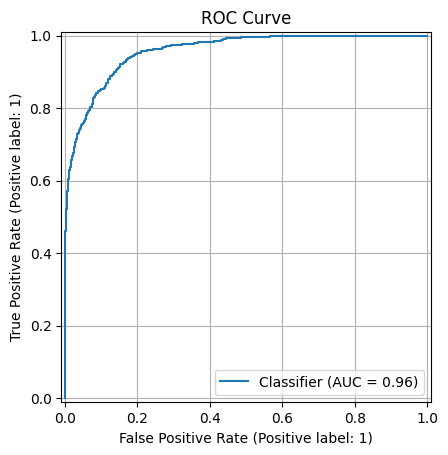

In [ ]:
print(f"\n🔵 ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Plot ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve")
plt.grid(True)
plt.show()

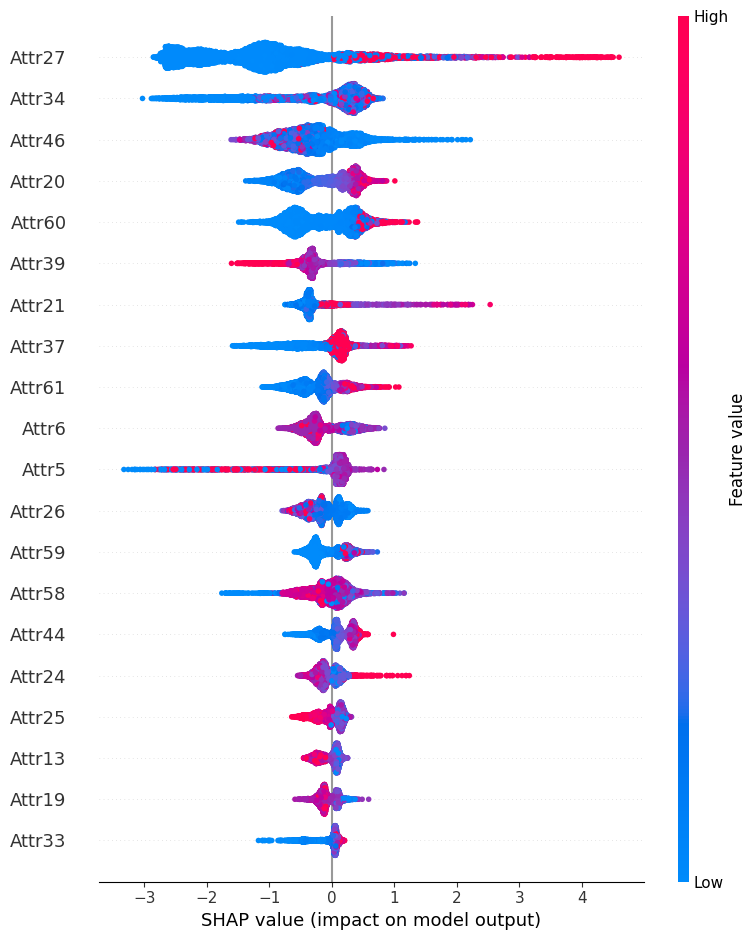

In [ ]:
# STEP 10: SHAP (Model Explainability)
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

In [ ]:
from google.colab import files
import pandas as pd

def predict_bankruptcy(company_data, model, scaler, threshold=0.5):
    """
    Predict bankruptcy for one company and return verdict string.

    Args:
      company_data (pd.Series): Single row with 64 attributes.
      model: Trained LightGBM model.
      scaler: Fitted scaler used in training.
      threshold: Probability cutoff to decide bankruptcy (default 0.5).

    Returns:
      str: Verdict message.
    """
    # Convert Series to DataFrame with one row
    company_df = company_data.to_frame().T

    # Scale
    scaled_data = scaler.transform(company_df)

    # Predict probability
    prob = model.predict_proba(scaled_data)[0, 1]

    # Predict class
    pred_class = 1 if prob >= threshold else 0

    if pred_class == 1:
        return f"⚠️ Company is likely to go bankrupt (probability: {prob:.2f})"
    else:
        return f"✅ Company is not likely to go bankrupt (probability: {prob:.2f})"


In [ ]:
!pip install --upgrade scikit-learn

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


In [ ]:
# Upload CSV file
uploaded = files.upload()

# Load uploaded CSV (assumes single file)
csv_file = next(iter(uploaded))
data_df = pd.read_csv(csv_file)

# Check columns (optional)
print("Columns in uploaded data:", data_df.columns.tolist())

# Run prediction for each company (row)
for idx, row in data_df.iterrows():
    verdict = predict_bankruptcy(row, model, scaler)
    print(f"Company {idx+1}: {verdict}")

Saving test_data.csv to test_data (6).csv
Columns in uploaded data: ['Attr1', 'Attr2', 'Attr3', 'Attr4', 'Attr5', 'Attr6', 'Attr7', 'Attr8', 'Attr9', 'Attr10', 'Attr11', 'Attr12', 'Attr13', 'Attr14', 'Attr15', 'Attr16', 'Attr17', 'Attr18', 'Attr19', 'Attr20', 'Attr21', 'Attr22', 'Attr23', 'Attr24', 'Attr25', 'Attr26', 'Attr27', 'Attr28', 'Attr29', 'Attr30', 'Attr31', 'Attr32', 'Attr33', 'Attr34', 'Attr35', 'Attr36', 'Attr37', 'Attr38', 'Attr39', 'Attr40', 'Attr41', 'Attr42', 'Attr43', 'Attr44', 'Attr45', 'Attr46', 'Attr47', 'Attr48', 'Attr49', 'Attr50', 'Attr51', 'Attr52', 'Attr53', 'Attr54', 'Attr55', 'Attr56', 'Attr57', 'Attr58', 'Attr59', 'Attr60', 'Attr61', 'Attr62', 'Attr63', 'Attr64']
Company 1: ✅ Company is not likely to go bankrupt (probability: 0.01)
Company 2: ✅ Company is not likely to go bankrupt (probability: 0.35)
Company 3: ✅ Company is not likely to go bankrupt (probability: 0.03)
Company 4: ✅ Company is not likely to go bankrupt (probability: 0.08)
Company 5: ✅ Company